# Ejercicio 4 - Eficiencia espectral con coseno realzado

Se dispone de un canal ideal con respuesta en frecuencia rectangular y un ancho de banda disponible de:

$$B = 10\;\text{MHz}$$

Se desea transmitir simbolos binarios utilizando un filtro coseno realzado con factor de roll-off:

$$\beta = 0.35$$

Suponiendo transmision libre de interferencia intersimbolica (ISI), se pide determinar:

1. La maxima tasa de simbolos que puede transmitirse a traves del canal.
2. Que ocurriria con la tasa maxima de simbolos si `beta = 1`.
3. Que ocurriria con la tasa maxima de simbolos si `beta = 0`.

## Teoria: ancho de banda y roll-off

Para un pulso coseno realzado, el ancho de banda positivo ocupado es:

$$B=\frac{(1+\beta)R_s}{2}$$

donde:

- `B` es el ancho de banda positivo disponible.
- `Rs` es la tasa de simbolos.
- `beta` es el factor de roll-off.

En los ejercicios anteriores usamos esta formula para calcular el ancho de banda a partir de `Rs`. En este ejercicio el dato conocido es el ancho de banda del canal, entonces despejamos `Rs`:

$$R_s=\frac{2B}{1+\beta}$$

Esta es la maxima tasa de simbolos compatible con ese ancho de banda y ese roll-off, suponiendo que el sistema cumple el criterio de Nyquist y no hay ISI en los instantes de muestreo.

## Teoria: eficiencia espectral

Si definimos eficiencia espectral en simbolos por segundo por Hertz como:

$$\eta_s=\frac{R_s}{B}$$

entonces usando la formula del coseno realzado:

$$B=\frac{(1+\beta)R_s}{2}$$

queda:

$$\eta_s=\frac{R_s}{B}=\frac{2}{1+\beta}$$

Esto muestra el efecto de `beta`:

- Si `beta` baja, se usa menos ancho de banda para la misma tasa de simbolos, entonces aumenta la eficiencia espectral.
- Si `beta` sube, se usa mas ancho de banda para la misma tasa de simbolos, entonces baja la eficiencia espectral.

El maximo teorico ocurre con `beta = 0`:

$$\eta_{s,max}=2\;\text{simbolos/s/Hz}$$

Pero ese caso corresponde al limite ideal tipo sinc, que es dificil de implementar exactamente porque su respuesta temporal se extiende infinitamente. Por eso en la practica se usan valores `beta > 0`, sacrificando eficiencia espectral a cambio de filtros mas realizables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Datos de la consigna
B = 10e6  # Hz, ancho de banda positivo disponible
beta = 0.35

print(f"Ancho de banda disponible B = {B/1e6:.2f} MHz")
print(f"Factor de roll-off beta = {beta}")

Ancho de banda disponible B = 10.00 MHz
Factor de roll-off beta = 0.35


# Punto 1 - Maxima tasa de simbolos para beta = 0.35

Usamos:

$$R_s=\frac{2B}{1+\beta}$$

Con `B = 10 MHz` y `beta = 0.35`:

$$R_s=\frac{2(10\times10^6)}{1+0.35}$$

$$R_s=\frac{20\times10^6}{1.35}$$

$$R_s\approx 14.81\times10^6\;\text{simbolos/s}$$

Entonces:

$$R_s\approx 14.81\;\text{Msimb/s}$$

In [2]:
Rs_max = 2 * B / (1 + beta)
eta = Rs_max / B

print(f"Rs maxima para beta = {beta}: {Rs_max/1e6:.4f} Msimb/s")
print(f"Eficiencia espectral eta = Rs/B = {eta:.4f} simb/s/Hz")

Rs maxima para beta = 0.35: 14.8148 Msimb/s
Eficiencia espectral eta = Rs/B = 1.4815 simb/s/Hz


# Punto 2 - Caso beta = 1

Si `beta = 1`, el ancho de banda del coseno realzado es:

$$B=\frac{(1+1)R_s}{2}=R_s$$

Entonces, si el canal tiene `B = 10 MHz`, la maxima tasa de simbolos es:

$$R_s=10\;\text{Msimb/s}$$

Este caso tiene menor eficiencia espectral que `beta = 0.35`, porque el roll-off es mas grande y se ocupa mas ancho de banda por cada simbolo transmitido.

# Punto 3 - Caso beta = 0

Si `beta = 0`, se obtiene el caso ideal de Nyquist de minimo ancho de banda:

$$B=\frac{R_s}{2}$$

Entonces:

$$R_s=2B$$

Con `B = 10 MHz`:

$$R_s=20\;\text{Msimb/s}$$

Este es el maximo teorico de eficiencia espectral, pero corresponde a un pulso ideal tipo sinc. En la practica es dificil de implementar exactamente, por eso se suelen usar valores de `beta` mayores que cero.

In [3]:
betas = np.array([0.35, 1.0, 0.0])
Rs_values = 2 * B / (1 + betas)
eta_values = Rs_values / B

print("Comparacion de casos")
print("---------------------")
for beta_i, Rs_i, eta_i in zip(betas, Rs_values, eta_values):
    print(f"beta = {beta_i:4.2f} | Rs_max = {Rs_i/1e6:7.4f} Msimb/s | eta = {eta_i:6.4f} simb/s/Hz")

Comparacion de casos
---------------------
beta = 0.35 | Rs_max = 14.8148 Msimb/s | eta = 1.4815 simb/s/Hz
beta = 1.00 | Rs_max = 10.0000 Msimb/s | eta = 1.0000 simb/s/Hz
beta = 0.00 | Rs_max = 20.0000 Msimb/s | eta = 2.0000 simb/s/Hz


## Grafica de la tasa maxima en funcion de beta

La siguiente grafica muestra como cambia la tasa maxima de simbolos cuando cambia `beta`, manteniendo fijo el ancho de banda del canal en `10 MHz`.

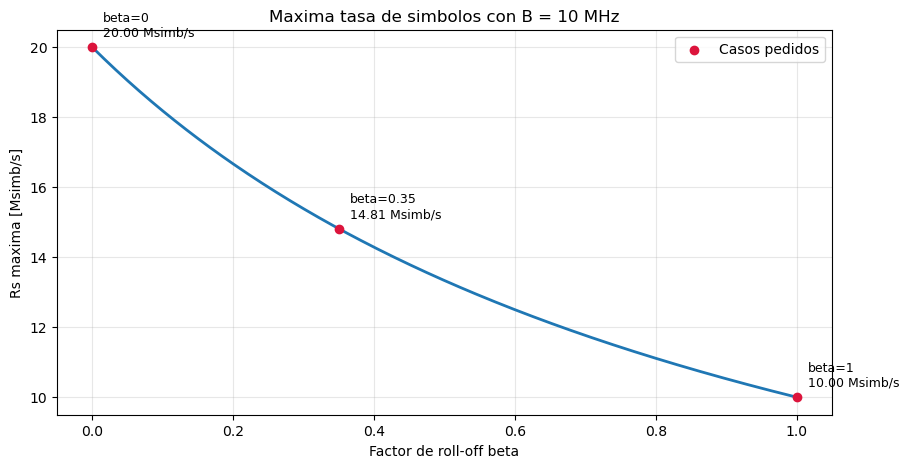

In [4]:
beta_grid = np.linspace(0, 1, 300)
Rs_grid = 2 * B / (1 + beta_grid)

plt.figure(figsize=(10, 5))
plt.plot(beta_grid, Rs_grid/1e6, linewidth=2)
plt.scatter(betas, Rs_values/1e6, color="crimson", zorder=5, label="Casos pedidos")

for beta_i, Rs_i in zip(betas, Rs_values):
    plt.annotate(f"beta={beta_i:g}\n{Rs_i/1e6:.2f} Msimb/s",
                 (beta_i, Rs_i/1e6),
                 textcoords="offset points",
                 xytext=(8, 8),
                 fontsize=9)

plt.title("Maxima tasa de simbolos con B = 10 MHz")
plt.xlabel("Factor de roll-off beta")
plt.ylabel("Rs maxima [Msimb/s]")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Conclusion

Para un canal de `10 MHz` y un filtro coseno realzado con `beta = 0.35`, la maxima tasa de simbolos que puede transmitirse sin ISI ideal es aproximadamente:

$$R_s=14.81\;\text{Msimb/s}$$

Si el roll-off aumenta a `beta = 1`, la tasa maxima baja a:

$$R_s=10\;\text{Msimb/s}$$

Si el roll-off baja al caso ideal `beta = 0`, la tasa maxima sube a:

$$R_s=20\;\text{Msimb/s}$$

La interpretacion es que `beta` controla el compromiso entre eficiencia espectral y realizabilidad practica. Un `beta` menor permite transmitir mas simbolos por segundo en el mismo ancho de banda, pero exige un filtro mas ideal y menos realizable. Un `beta` mayor reduce la tasa maxima posible, pero hace mas suave la transicion espectral y facilita la implementacion.